In [101]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
# Load your CSV
df= pd.read_csv('social_network_data.csv', index_col=0)


In [102]:
df

,1,2,3,4,5,6,7,8,9,10,...,241,242,243,244,245,246,247,248,249,250
Actor,,,,,,,,,,,,,,,,,,,,,
1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
5,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
247,0,0,0,1,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
248,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [103]:
#Taking random 50 samples to see edges more clearly
df = df.sample(n=50, random_state=42)

In [104]:
df.columns = df.columns.astype(int)
df.index = df.index.astype(int)

In [105]:
# Build a directed graph from the adjacency matrix
G = nx.from_pandas_adjacency(df, create_using=nx.DiGraph)

In [106]:
# Basic stats
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Density:", nx.density(G))
print("Reciprocity:", nx.reciprocity(G))

Nodes: 50
Edges: 165
Density: 0.0673469387755102
Reciprocity: 0.6545454545454545


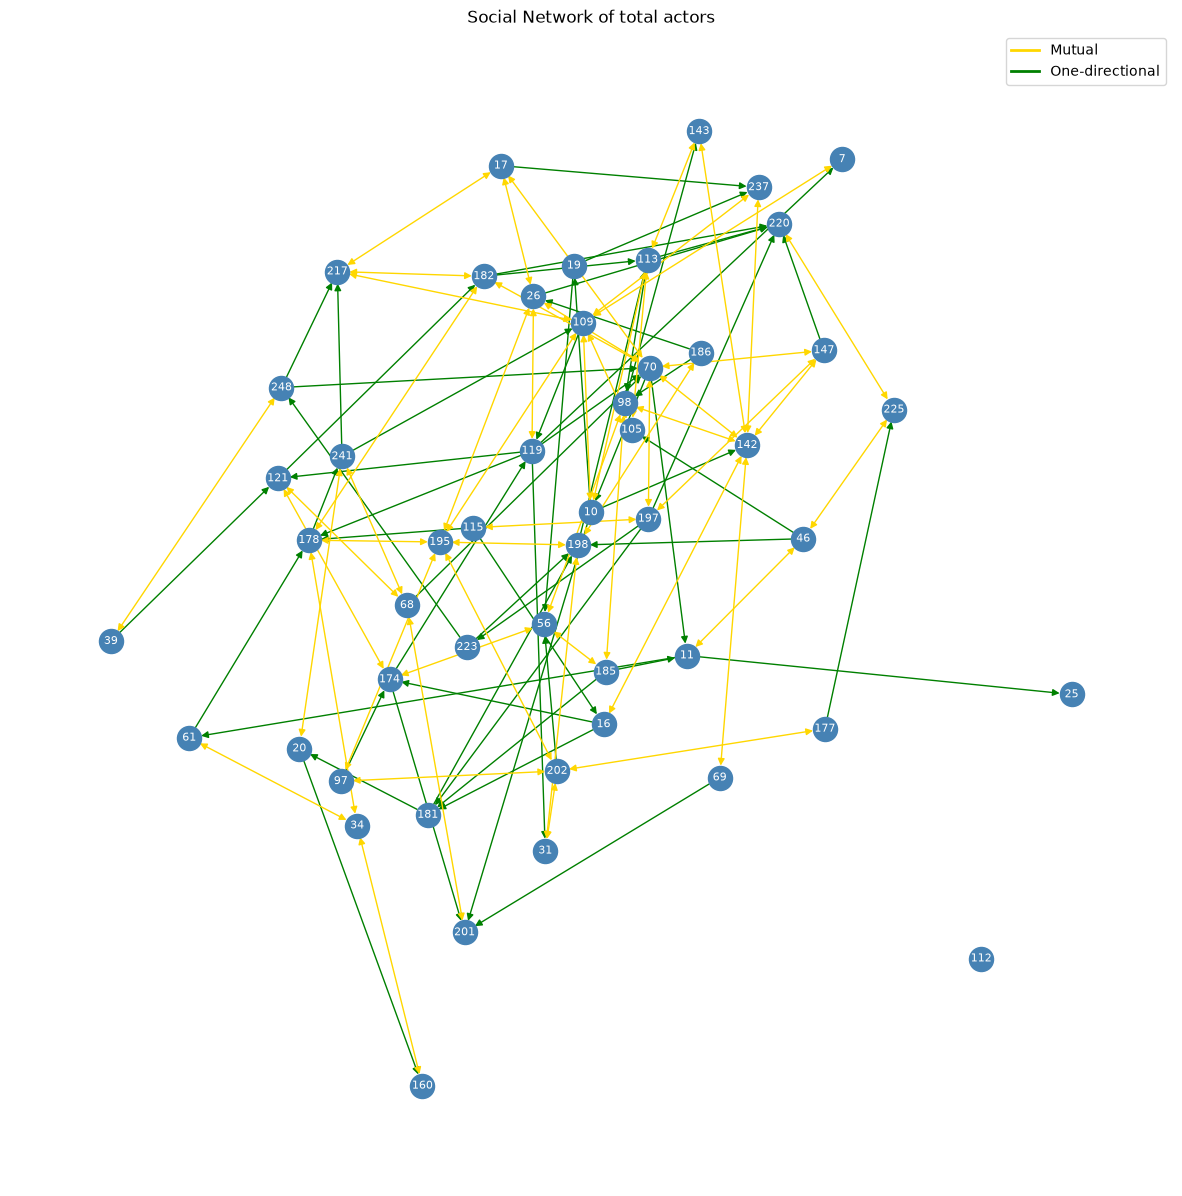

In [107]:
plt.figure(figsize=(15, 15))
pos = nx.spring_layout(G, k=0.5, seed=42)

# Deduplicate mutual pairs, keep one-directional edges as-is
drawn_pairs = set()
mutual_pairs = []
onedir_edges = []
for u, v in G.edges():
    if G.has_edge(v, u):
        pair = tuple(sorted((u, v)))
        if pair not in drawn_pairs:
            drawn_pairs.add(pair)
            mutual_pairs.append(pair)
    else:
        onedir_edges.append((u, v))

# Nodes + labels
nx.draw_networkx_nodes(G, pos, node_size=300, node_color='steelblue')
nx.draw_networkx_labels(G, pos, font_color='white',font_size=8)

# One-directional edges: single arrowhead, green
nx.draw_networkx_edges(G, pos, edgelist=onedir_edges,edge_color='green', width=1, arrowsize=10, arrowstyle='-|>')
# Mutual pairs: single line, double arrowhead, gold
nx.draw_networkx_edges(G, pos, edgelist=mutual_pairs,edge_color='gold', width=1, arrowsize=10, arrowstyle='<|-|>')

plt.plot([], [], color='gold', label='Mutual', linewidth=2)
plt.plot([], [], color='green', label='One-directional', linewidth=2)
plt.legend(loc='upper right')

plt.title("Social Network of total actors")
plt.axis('off')
plt.show()

In [108]:
# Pick the actor you want to analyze
ego_node = 143

# Extract ego network: ego + direct neighbors (both directions)
ego_graph = nx.ego_graph(G, ego_node,undirected=True, radius=2, )# radius=1 if taking only direct connections.

print(f"Actor {ego_node}'s network:")
print("Nodes (including self):", ego_graph.number_of_nodes())
print("Edges:", ego_graph.number_of_edges())
print("In-degree (received ties):", G.in_degree(ego_node))
print("Out-degree (sent ties):", G.out_degree(ego_node))



Actor 143's network:
Nodes (including self): 17
Edges: 42
In-degree (received ties): 3
Out-degree (sent ties): 2


In [109]:
# Count relationship types
mutual = 0
outgoing = 0
incoming = 0

for u, v in G.edges():
    if u == ego_node:
        if G.has_edge(v, ego_node):
            mutual += 1
        else:
            outgoing += 1

    elif v == ego_node:
        if not G.has_edge(ego_node, u):
            incoming += 1

print("\nRelationship types:")
print("Mutual:", mutual)
print("Outgoing:", outgoing)
print("Incoming:", incoming)




Relationship types:
Mutual: 2
Outgoing: 0
Incoming: 1


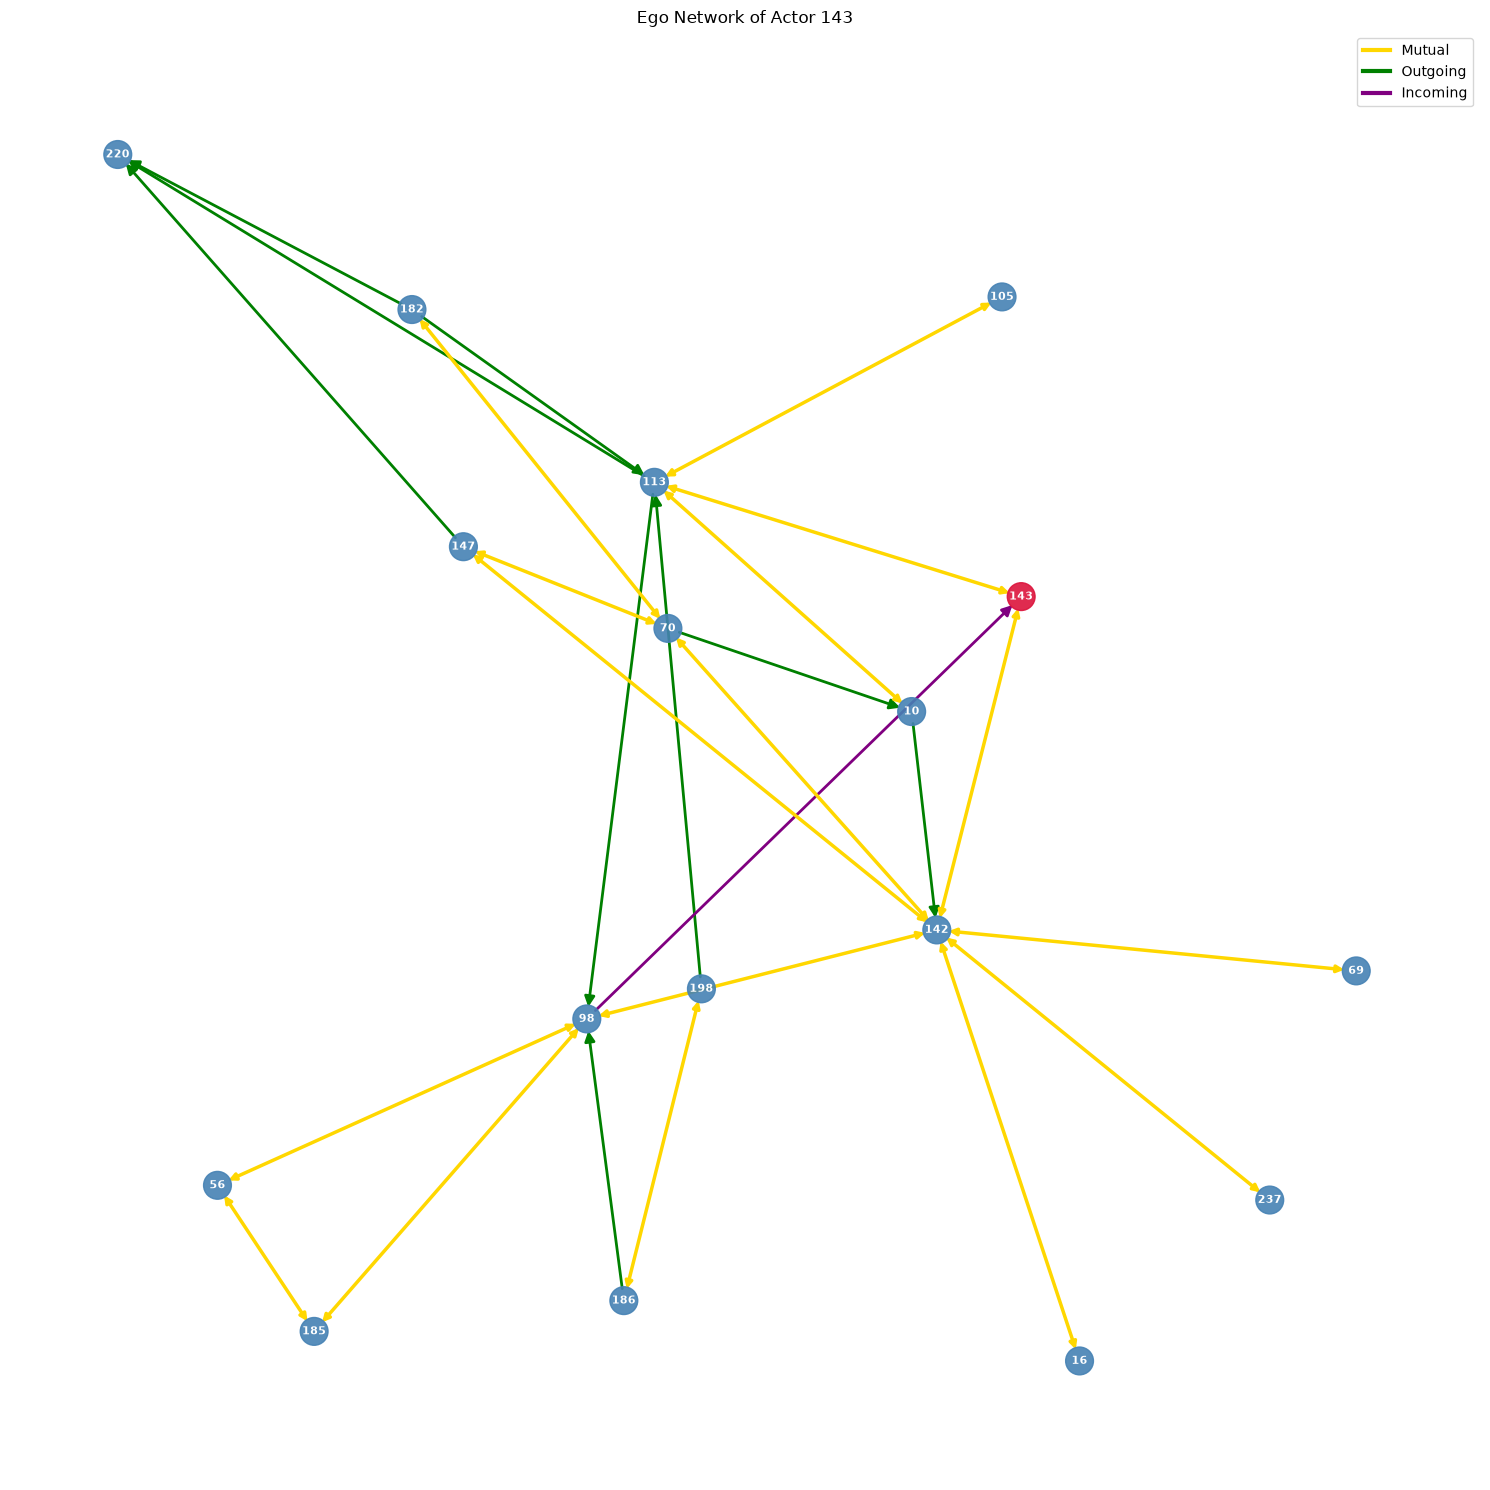

In [110]:
# Separate edges by type
drawn_pairs = set()
mutual_edges = []
outgoing_edges = []
incoming_edges = []

for u, v in ego_graph.edges():
    # Check for mutual edges
    if ego_graph.has_edge(v, u):
        pair = tuple(sorted((u, v)))
        if pair not in drawn_pairs:
            drawn_pairs.add(pair)
            mutual_edges.append(pair)
    # Outgoing from ego
    elif u == ego_node:
        outgoing_edges.append((u, v))
    # Incoming to ego
    elif v == ego_node:
        incoming_edges.append((u, v))
    # Edges between neighbors
    else:
        outgoing_edges.append((u, v))

# Visualize ego network
plt.figure(figsize=(15, 15))

ego_pos = nx.spring_layout(ego_graph, k=0.5, seed=42)
node_colors = ['crimson' if node == ego_node else 'steelblue' for node in ego_graph.nodes()]

# Draw nodes
nx.draw_networkx_nodes(ego_graph, ego_pos, node_size=400, node_color=node_colors, alpha=0.9)
nx.draw_networkx_labels(ego_graph, ego_pos, font_size=8, font_color='white', font_weight='bold')

# Draw outgoing edges (single arrow →)
nx.draw_networkx_edges(ego_graph, ego_pos,edgelist=outgoing_edges,edge_color='green',width=2,arrows=True,arrowsize=15,arrowstyle='-|>')

# Draw incoming edges (single arrow ←)
nx.draw_networkx_edges(ego_graph, ego_pos,edgelist=incoming_edges,edge_color='purple',width=2,arrows=True,arrowsize=15,arrowstyle='-|>')

# Draw mutual edges (bidirectional ↔)
nx.draw_networkx_edges(ego_graph, ego_pos,edgelist=mutual_edges,edge_color='gold',width=2.5,arrows=True,arrowstyle='<|-|>',)

# Legend
plt.plot([], [], color='gold', linewidth=3, label='Mutual', marker='o', markersize=0)
plt.plot([], [], color='green', linewidth=3, label='Outgoing', marker='o', markersize=0)
plt.plot([], [], color='purple', linewidth=3, label='Incoming', marker='o', markersize=0)

plt.legend(loc='best')
plt.title(f"Ego Network of Actor {ego_node}")
plt.axis('off')
plt.tight_layout()
plt.show()